# Redes Convolucionales

Generado por la cátedra de Introducción a la Inteligencia Artificial de la  Licenciatura en Ciencias de la Computación - UNR

Autor: Nicolás Soncini

In [1]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random

from datasets import load_dataset

# Tensorflow es un a librería o motor de machine learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# chequeamos las versiones de las librerias y si tenemos GPU
# (dato de color: la traducción de "library" debería ser biblioteca, y no librería)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Keras version: {keras.__version__}")

I0000 00:00:1781568594.693996   84005 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781568595.009396   84005 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781568596.791280   84005 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Keras version: 3.14.1


W0000 00:00:1781568598.183090   84005 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## Dataset

In [2]:
ds = load_dataset("uoft-cs/cifar10")

print(ds)

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})


In [3]:
LABELS = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

num_classes = len(LABELS)
print(f"Number of classes: {num_classes}")

Number of classes: 10


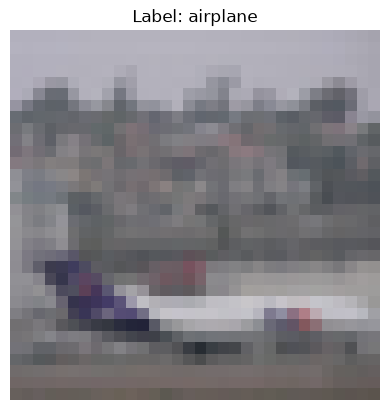

In [4]:
# extraemos cada dataset (train/test) por separado
ds_train = ds['train']
ds_test = ds['test']

# Se muestra un ejemplo de imagen del dataset de train
plt.imshow(ds_train[0]['img'])
plt.title(f'Label: {LABELS[ds_train[0]['label']]}')
plt.axis('off')
plt.show()

## Ejercicio 1. Visión por Computadora
Entrene una red convolucional como la mostrada en el tutorial anterior sobre el dataset CIFAR-10. La red tiene
que tener las siguientes capas:

1. Conv, filtro 3x3, 32 filtros, con padding para que conserve el tamaño de 32x32, Relu.
2. Maxpooling 2x2 (es el valor por defecto)
3. Conv, filtro 3x3, 64 filtros, con padding, Relu.
4. Conv, filtro 3x3, 64 filtros, con padding, Relu.
5. Maxpooling 2x2
6. Conv, filtro 3x3, 64 filtros, con padding, Relu.
7. Conv, filtro 3x3, 64 filtros, con padding, Relu.
8. Densa, 64
9. Densa, 128
10. Densa, 128
11. Densa, 10 (salida)

Usen como base el ejemplo del tutorial (ver la capa de aplanado al pasar de convolución a densa!), con los
mismos parámetros para el entrenamiento. Obtengan las curvas de error en train y validación, y el valor de
error en test del modelo final. Analice los resultados.
Plantee una modificación de la arquitectura de la CNN, utilizando sólo capas convolucionales, de pooling o
densas, de forma adecuada, para obtener una mejora en el error obtenido (al menos un 3% de mejora) sobre
los resultados anteriores. Trate de justificar por qué su diseño mejora respecto a la arquitectura anterior.

In [5]:
# Extraemos todo el dataset a memoria como matrices de numpy
x_train = np.array([np.array(element) for element in ds_train['img']])
y_train = np.array(ds_train['label'])

# Normalizamos los valores de cada imágen al rango [0, 1]
x_train = x_train.astype('float32') / 255.0

x_test = np.array([np.array(element) for element in ds_test['img']])
y_test = np.array(ds_test['label'])

x_test = x_test.astype('float32') / 255.0

In [6]:
def create_cnn_model(input_shape=(32, 32, 3), num_classes=10):
    model = keras.Sequential([
        # Input Layer
        keras.Input(shape=input_shape),

        # Layer 1: Conv2D with 32 filters, 3x3 kernel, ReLU activation
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_1'),

        # Layer 2: MaxPooling2D with 2x2 pool size. (maxpooling takes each 2x2 area and narrows it down to a single pixel which has the max value among those)
        layers.MaxPooling2D((2, 2), name='maxpool2d_1'),

        # Layer 3: Conv2D with 64 filters, 3x3 kernel, ReLU activation
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'),

        # Layer 4: Igual a la anterior.
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),

        # Layer 5: MaxPooling2D with 2x2 pool size
        layers.MaxPooling2D((2, 2), name='maxpool2d_2'),

        # Layer 6 : Igual a 3 y 4
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),

        # Layer 7 : Igual a 3 y 4
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),

        # Extractor de caracteristicas
        layers.Flatten(name='flatten'),

        # Layer 8: Dense layer with 64 units, ReLU activation.
        layers.Dense(64, activation='relu', name='dense_1'),

        # Layer 9: Densa con 128.
        layers.Dense(128, activation='relu', name='dense_2'),

        # Layer 10: Densa con 128.
        layers.Dense(128, activation='relu', name='dense_3'),

        # Layer 11: Capa densa de salida.
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='lccCIFAR')

    return model


cnn_model = create_cnn_model()
cnn_model.summary()

W0000 00:00:1781568625.069812   84005 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1781568625.260979   84005 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5199 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "lccCIFAR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,506 (1.60 MB)

 Trainable params: 418,506 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Entrenar la red
# Usamos learning rate = 0.001 pues del anterior tp concluimos que era un posible valor adecuado
optimizer = keras.optimizers.Adam(learning_rate=0.001)

loss = keras.losses.SparseCategoricalCrossentropy()

metrics = [
    keras.metrics.SparseCategoricalAccuracy(name='accuracy')
]

# Compilar el modelo
cnn_model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

In [8]:
# Separamos en train y validación

# stratify se encarga que al hacer la division, en los subconjuntos resultantes se mantenga las proporciones
# de clases del conjunto original
x_train_processed, x_val_processed, y_train_processed, y_val_processed = \
    train_test_split(x_train, y_train, test_size=0.25, stratify=y_train)

print(len(x_train_processed), len(x_val_processed))

37500 12500


In [9]:
history = cnn_model.fit(x_train_processed, y_train_processed, epochs=15,
                  validation_data=(x_val_processed, y_val_processed), verbose=1)
print("Entrenamiento completado!!")

Epoch 1/15


I0000 00:00:1781568646.114024   84645 service.cc:153] XLA service 0x41c441b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781568646.114061   84645 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.1)
I0000 00:00:1781568646.230311   84645 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781568646.651345   84645 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1781568646.691487   84645 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3090__.35


  40/1172 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.0937 - loss: 2.3044 

I0000 00:00:1781568655.717647   84645 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3021 - loss: 1.8517

I0000 00:00:1781568660.758676   84645 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3090__.35
I0000 00:00:1781568662.917298   85134 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 8 bytes spill stores, 8 bytes spill loads



1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3022 - loss: 1.8515

I0000 00:00:1781568670.496400   85593 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1781568670.554192   85597 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8 bytes spill stores, 8 bytes spill loads



1172/1172 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.3884 - loss: 1.6442 - val_accuracy: 0.4961 - val_loss: 1.3387
Epoch 2/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5598 - loss: 1.2260 - val_accuracy: 0.6080 - val_loss: 1.0855
Epoch 3/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6393 - loss: 1.0211 - val_accuracy: 0.6302 - val_loss: 1.0314
Epoch 4/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6912 - loss: 0.8807 - val_accuracy: 0.6695 - val_loss: 0.9423
Epoch 5/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7275 - loss: 0.7686 - val_accuracy: 0.6919 - val_loss: 0.8942
Epoch 6/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7618 - loss: 0.6863 - val_accuracy: 0.7071 - val_loss: 0.8532
Epoch 7/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7894 - loss: 0.6041 - val_accuracy: 0.7117 - val_loss: 0.8607
Epoch 8/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8153 - loss: 0.5327 - val_accur

## Calculamos los errores y graficamos

Esta función nos sirve para graficar un solo modelo.

In [22]:
def plot_history_graphics(history, model, legend):
    fig = plt.figure(figsize=(15, 5))

    # Plot training & validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy ' + legend)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot training & validation loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss ' + legend)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print final training results
    print("Final Training Results:")
    print(f"Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")
    print("")

    # Evaluamos el modelo con los datos de prueba, evaluate devuelve una lista donde el pimrer valor es el loss y el segundo la accuracy
    resultados_test = model.evaluate(x_test, y_test, verbose=1)

    test_loss = resultados_test[0]
    test_accuracy = resultados_test[1]

    print(f"\n--- Resultados Finales en Test ---")
    print(f"Error (Loss) en Test: {test_loss:.4f}")
    print(f"Precisión (Accuracy) en Test: {test_accuracy * 100:.2f}%")

Esta función por otro lado, nos sirve para plotear varios modelos a la misma escala, uno al lado del otro.

In [10]:
def compare_metrics_side_by_side(histories_dict):
    """
    histories_dict: {'sin dropout': history1, 'dropout 0.2': history2, ...}
    Crea una grilla de 2 filas x N columnas.
    Fila 1: Curvas de Train/Val Loss (escala Y compartida).
    Fila 2: Curvas de Train/Val Accuracy (escala Y compartida).
    """
    n = len(histories_dict)

    # Creamos la figura con 2 filas y 'n' columnas
    # sharey='row' hace que compartan el eje Y por fila
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 10), sharey='row')

    # Si solo hay un modelo, axes es un array 1D. Lo convertimos a 2D para iterar consistentemente
    if n == 1:
        axes = axes.reshape(2, 1)

    for i, (label, h) in enumerate(histories_dict.items()):
        # -- Fila 0: Gráficos de LOSS --
        ax_loss = axes[0, i]
        ax_loss.plot(h.history['loss'], label='Train Loss')
        ax_loss.plot(h.history['val_loss'], label='Validation Loss')
        ax_loss.set_title(f"Loss: {label}")
        ax_loss.set_xlabel('Epoch')
        ax_loss.legend()
        ax_loss.grid(True, alpha=0.3)

        # -- Fila 1: Gráficos de ACCURACY --
        ax_acc = axes[1, i]
        ax_acc.plot(h.history['accuracy'], label='Train Accuracy')
        ax_acc.plot(h.history['val_accuracy'], label='Validation Accuracy')
        ax_acc.set_title(f"Accuracy: {label}")
        ax_acc.set_xlabel('Epoch')
        ax_acc.legend()
        ax_acc.grid(True, alpha=0.3)

    # Solo colocamos la etiqueta del eje Y en la primera columna para que quede más limpio
    axes[0, 0].set_ylabel('Loss')
    axes[1, 0].set_ylabel('Accuracy')

    plt.tight_layout()
    plt.show()

Con esta funcion validamos el test accuracy.


In [11]:
def show_test(testdict):

  for desc, mod in testdict.items():
    # Evaluamos el modelo con los datos de prueba, evaluate devuelve una lista donde el pimrer valor es el loss y el segundo la accuracy
      resultados_test = mod.evaluate(x_test, y_test, verbose=1)

      test_loss = resultados_test[0]
      test_accuracy = resultados_test[1]

      print(f"\n--- Resultados Finales en Test ({desc}) ---")
      print(f"Error (Loss) en Test): {test_loss:.4f}")
      print(f"Precisión (Accuracy) en Test: {test_accuracy * 100:.2f}%")

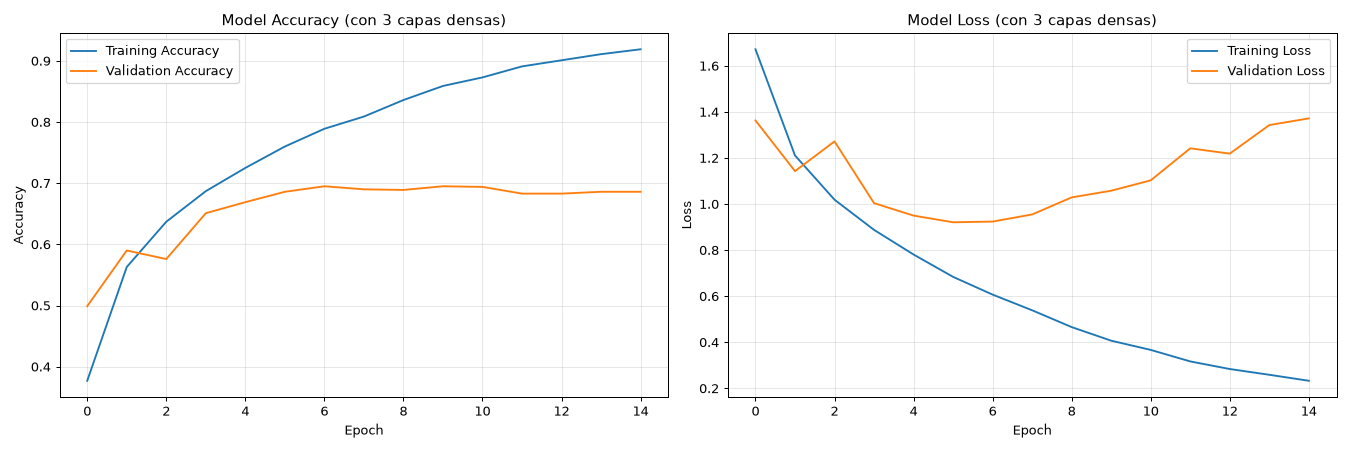

Final Training Results:
Training Accuracy: 0.9190
Validation Accuracy: 0.6860
Training Loss: 0.2330
Validation Loss: 1.3720


--- Resultados Finales en Test ---
Error (Loss) en Test: 1.3929
Precisión (Accuracy) en Test: 68.00%


In [38]:
plot_history_graphics(history, cnn_model, "(con 3 capas densas)")

Decidimos realizar el entrenamiento con $15$ épocas.

Vemos como rápidamente la red sobreajusta a partir de la época 6 más o menos, ya que aquí es donde el error de validación empieza a subir rápidamente mientras que el de train baja.

Esto se debe a la gran cantidad de capas densas y también a la no progresión de las capas convolucionales, dónde suponemos que si añadimos más capas convolucionales con una cantidad progresiva de filtros mejorará el rendimiento de la red. Además, la primera capa Flatten de $8\times8\times64 = 4096$ entradas hace que haya alrededor de 262k parámetros para la primer capa densa (de los 418k totales), dándole a la red mucha capacidad para memorizar el conjunto de entrenamiento. También, pensamos que el hecho de que las capas densas consecutivas aumenten en su cantidad de neuronas tampoco aporta mucho.

Buscaremos entonces una red que tenga más capas de convolución (que "extraen" características de las imágenes) y menos densas, así bajamos la cantidad de parámetros que le llega a la primer capa densa.

In [12]:
modeloProgresivo = keras.Sequential([
    layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32,32,3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),                    # 32x32 -> 16x16

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),                    # 16x16 -> 8x8

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),                    # 8x8 -> 4x4

    layers.Flatten(name="flatten_b"),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

modeloProgresivo.summary()

modeloProgresivo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)

/home/bussa/IIA/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_b (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
historyProg = modeloProgresivo.fit(x_train_processed, y_train_processed, epochs=15,
                  validation_data=(x_val_processed, y_val_processed), verbose=1)
print("Entrenamiento completado!!")

Epoch 1/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9515 - loss: 0.1440 - val_accuracy: 0.7350 - val_loss: 1.2940
Epoch 2/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9550 - loss: 0.1348 - val_accuracy: 0.7375 - val_loss: 1.4340
Epoch 3/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9568 - loss: 0.1274 - val_accuracy: 0.7362 - val_loss: 1.4210
Epoch 4/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9567 - loss: 0.1277 - val_accuracy: 0.7465 - val_loss: 1.4614
Epoch 5/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9600 - loss: 0.1176 - val_accuracy: 0.7346 - val_loss: 1.4904
Epoch 6/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9611 - loss: 0.1155 - val_accuracy: 0.7299 - val_loss: 1.6557
Epoch 7/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9594 - loss: 0.1259 - val_accuracy: 0.7347 - val_loss: 1.4395
Epoch 8/15
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9635 - loss: 0.1120 - 

Imprimiendo resultados

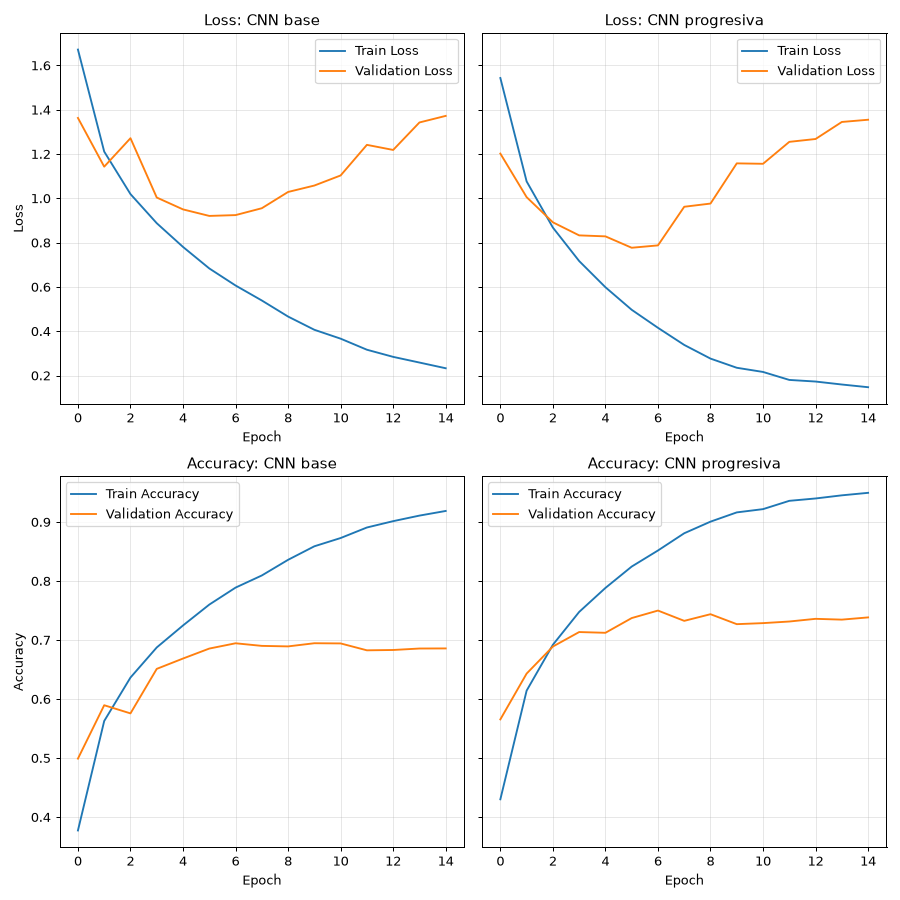


--- Resultados Finales en Test (CNN base) ---
Error (Loss) en Test): 1.3929
Precisión (Accuracy) en Test: 68.00%

--- Resultados Finales en Test (CNN progresiva) ---
Error (Loss) en Test): 1.3796
Precisión (Accuracy) en Test: 73.56%


In [20]:
dict = {
        'CNN base': history,
        'CNN progresiva': historyProg}

compare_metrics_side_by_side(dict)

show_test({
    'CNN base': cnn_model,
    'CNN progresiva': modeloProgresivo
})

## Conclusiones

Efectivamente, agregando un tercer bloque convolucional con más filtros que antes y un tercer max-pooling, la red progresiva mejora en test de 68.00% a 73.56%, superando el 3% pedido, y además con un loss menor (1.3796 vs 1.3929): no solo acierta más, sino que generaliza mejor (aunque esto podría haber ocurrido gracias a la aleatoriedad del entrenamiento).
El efecto se ve en las curvas ya que la red progresiva alcanza un mínimo de error de validación más bajo y un máximo de accuracy en validación más alto. De todas formas, ambas redes igualmente sobreajustan a partir de la época 6 o 7.

## Ejercicio 2. Dropout

Agregue regularización por Dropout a la red planteada en el ejercicio anterior. Primero con una capa Dropout
luego de la última capa convolucional, y luego agregando al anterior una segunda capa de dropout luego de la
primer capa densa.
Pruebe dos valores de p en cada caso, 0.2 y 0.5 (al agregar dropout se recomienda duplicar las épocas de
entrenamiento porque el azar dificulta el aprendizaje). Obtenga las curvas de entrenamiento y validación, y el
error de test. Analice los resultados.


Red convolucional con 1 dropout luego de las capas convolucionales ($p = 0.2$)

In [58]:
cnnDropout1 = keras.Sequential([
    layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32,32,3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.Conv2D(128, 3, padding='same', activation='relu'),

    layers.MaxPooling2D(),

    layers.Dropout(0.2, name='dropout_1'),

    layers.Flatten(name="flatten_b"),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

cnnDropout1
cnnDropout1.summary()

cnnDropout1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_b (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

Red convolucional con 1 dropout luego de las capas convolucionales ($p = 0.5$)

In [52]:
cnnDropout2 = keras.Sequential([
    layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32,32,3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.Conv2D(128, 3, padding='same', activation='relu'),

    layers.MaxPooling2D(),

    layers.Dropout(0.5, name='dropout_1'),

    layers.Flatten(name="flatten_b"),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

cnnDropout2
cnnDropout2.summary()

cnnDropout2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_b (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

Red convolucional con 2 capas dropout luego de las capas convolucionales y luego de las capas densas (ambas con $p = 0.2$)

In [53]:
cnnDropout3 = keras.Sequential([
    layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32,32,3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.Conv2D(128, 3, padding='same', activation='relu'),

    layers.MaxPooling2D(),

    layers.Dropout(0.2, name='dropout_1'),

    layers.Flatten(name="flatten_b"),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2, name='dropout_2'),
    layers.Dense(10, activation='softmax'),
])

cnnDropout3
cnnDropout3.summary()

cnnDropout3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_b (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

Red convolucional con 2 capas dropout luego de las capas convolucionales y luego de las capas densas (ambas con $p = 0.5$)

In [54]:
cnnDropout4 = keras.Sequential([
    layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32,32,3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.Conv2D(128, 3, padding='same', activation='relu'),

    layers.MaxPooling2D(),

    layers.Dropout(0.5, name='dropout_1'),

    layers.Flatten(name="flatten_b"),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5, name='dropout_2'),
    layers.Dense(10, activation='softmax'),
])

cnnDropout4
cnnDropout4.summary()

cnnDropout4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_b (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
cantEpocas = 30

In [59]:
history1 = cnnDropout1.fit(x_train_processed, y_train_processed, epochs=cantEpocas,
                  validation_data=(x_val_processed, y_val_processed), verbose=1)
print("Entrenamiento completado!!")

Epoch 1/30


I0000 00:00:1781554414.882887    3590 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1454620__.43


1169/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3125 - loss: 1.8633

I0000 00:00:1781554422.125061    3592 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1454620__.43


1172/1172 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.4062 - loss: 1.6157 - val_accuracy: 0.5350 - val_loss: 1.2696
Epoch 2/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6010 - loss: 1.1134 - val_accuracy: 0.6615 - val_loss: 0.9467
Epoch 3/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6815 - loss: 0.8932 - val_accuracy: 0.7008 - val_loss: 0.8370
Epoch 4/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7341 - loss: 0.7554 - val_accuracy: 0.7165 - val_loss: 0.8040
Epoch 5/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7715 - loss: 0.6512 - val_accuracy: 0.7390 - val_loss: 0.7507
Epoch 6/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7983 - loss: 0.5680 - val_accuracy: 0.7424 - val_loss: 0.7550
Epoch 7/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8259 - loss: 0.4897 - val_accuracy: 0.7520 - val_loss: 0.7362
Epoch 8/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8495 - loss: 0.4285 - val_accura

In [56]:
history2 = cnnDropout2.fit(x_train_processed, y_train_processed, epochs=cantEpocas,
                  validation_data=(x_val_processed, y_val_processed), verbose=1)
print("Entrenamiento completado!!")

Epoch 1/30


I0000 00:00:1781554200.702141    3595 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1263049__.43


1164/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2907 - loss: 1.8858

I0000 00:00:1781554208.343334    3593 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1263049__.43
I0000 00:00:1781554208.511319   30527 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 12 bytes spill stores, 12 bytes spill loads



1172/1172 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3920 - loss: 1.6388 - val_accuracy: 0.5243 - val_loss: 1.3036
Epoch 2/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5704 - loss: 1.1979 - val_accuracy: 0.6272 - val_loss: 1.0568
Epoch 3/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6362 - loss: 1.0185 - val_accuracy: 0.6706 - val_loss: 0.9462
Epoch 4/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6838 - loss: 0.8965 - val_accuracy: 0.6860 - val_loss: 0.8827
Epoch 5/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7143 - loss: 0.8064 - val_accuracy: 0.7021 - val_loss: 0.8343
Epoch 6/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7393 - loss: 0.7363 - val_accuracy: 0.7353 - val_loss: 0.7585
Epoch 7/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7614 - loss: 0.6755 - val_accuracy: 0.7390 - val_loss: 0.7620
Epoch 8/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7752 - loss: 0.6360 - val_accura

In [60]:
history3 = cnnDropout3.fit(x_train_processed, y_train_processed, epochs=cantEpocas,
                  validation_data=(x_val_processed, y_val_processed), verbose=1)
print("Entrenamiento completado!!")

Epoch 1/30


I0000 00:00:1781554606.818554    3592 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1646066__.44


1169/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3101 - loss: 1.8373

I0000 00:00:1781554614.701110    3588 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1646066__.44


1172/1172 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4051 - loss: 1.6023 - val_accuracy: 0.5645 - val_loss: 1.1875
Epoch 2/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6000 - loss: 1.1237 - val_accuracy: 0.6609 - val_loss: 0.9374
Epoch 3/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6711 - loss: 0.9291 - val_accuracy: 0.6866 - val_loss: 0.8995
Epoch 4/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7151 - loss: 0.8124 - val_accuracy: 0.7220 - val_loss: 0.7878
Epoch 5/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7515 - loss: 0.7142 - val_accuracy: 0.6871 - val_loss: 0.9380
Epoch 6/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7764 - loss: 0.6376 - val_accuracy: 0.7359 - val_loss: 0.7798
Epoch 7/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8010 - loss: 0.5646 - val_accuracy: 0.7594 - val_loss: 0.7191
Epoch 8/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8174 - loss: 0.5172 - val_accura

In [61]:
history4 = cnnDropout4.fit(x_train_processed, y_train_processed, epochs=cantEpocas,
                  validation_data=(x_val_processed, y_val_processed), verbose=1)
print("Entrenamiento completado!!")

Epoch 1/30


I0000 00:00:1781554808.121038    3590 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1837514__.44


1163/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2631 - loss: 1.9561

I0000 00:00:1781554815.833296    3590 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1837514__.44


1172/1172 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3509 - loss: 1.7435 - val_accuracy: 0.5015 - val_loss: 1.3567
Epoch 2/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5125 - loss: 1.3432 - val_accuracy: 0.5945 - val_loss: 1.1339
Epoch 3/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5900 - loss: 1.1539 - val_accuracy: 0.6367 - val_loss: 1.0160
Epoch 4/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6373 - loss: 1.0278 - val_accuracy: 0.6809 - val_loss: 0.8862
Epoch 5/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6692 - loss: 0.9430 - val_accuracy: 0.7042 - val_loss: 0.8399
Epoch 6/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6965 - loss: 0.8701 - val_accuracy: 0.7197 - val_loss: 0.7934
Epoch 7/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7155 - loss: 0.8176 - val_accuracy: 0.7317 - val_loss: 0.7662
Epoch 8/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7341 - loss: 0.7667 - val_accura

Necesitamos otro código para graficar ya que usar plot_history_graphics puede ser confuso, ya que se ajusta la escala dependiendo de los valores de history.

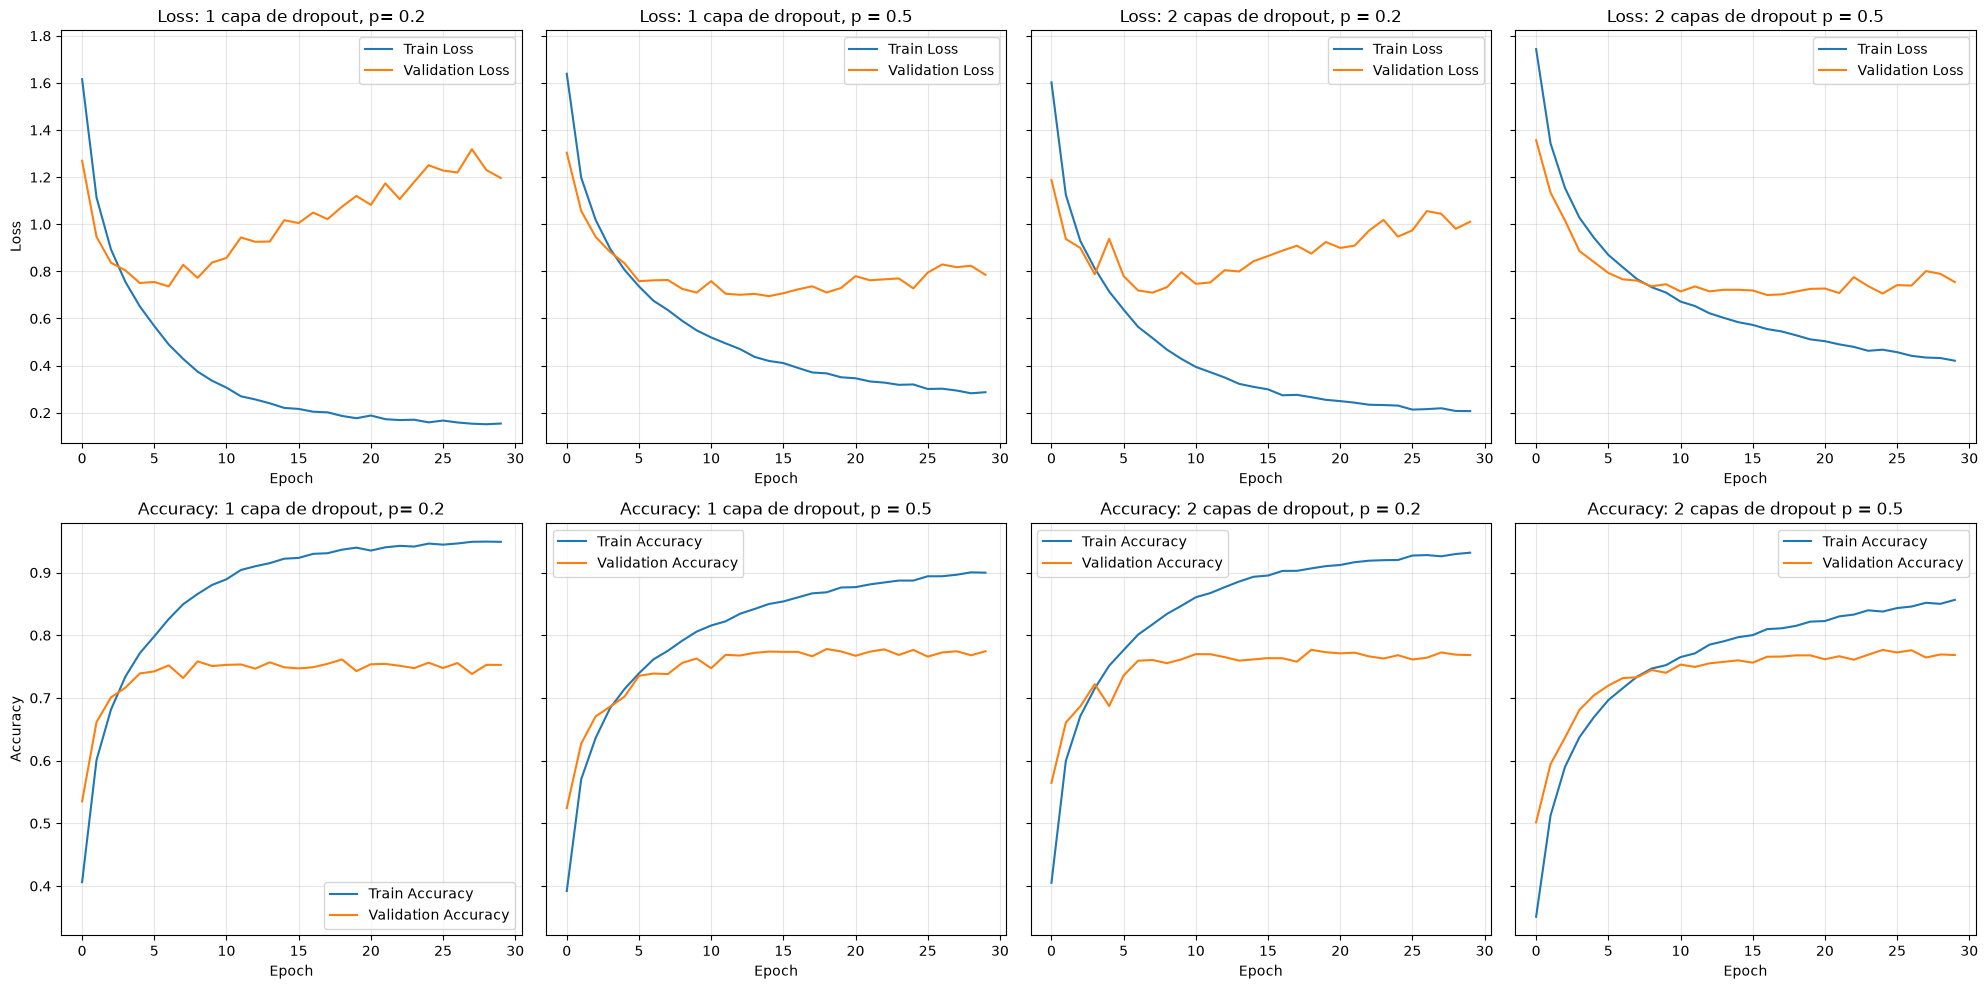

In [62]:
diccionario = {
    '1 capa de dropout, p= 0.2': history1,
    '1 capa de dropout, p = 0.5': history2,
    '2 capas de dropout, p = 0.2': history3,
    '2 capas de dropout p = 0.5': history4
}

compare_metrics_side_by_side(diccionario)

In [63]:
tdict = {
    '1 capa de dropout, p= 0.2': cnnDropout1,
    '1 capa de dropout, p = 0.5': cnnDropout2,
    '2 capas de dropout, p = 0.2': cnnDropout3,
    '2 capas de dropout p = 0.5': cnnDropout4
}

show_test(tdict)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7364 - loss: 1.2879

--- Resultados Finales en Test (1 capa de dropout, p= 0.2) ---
Error (Loss) en Test): 1.2879
Precisión (Accuracy) en Test: 73.64%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7767 - loss: 0.7896

--- Resultados Finales en Test (1 capa de dropout, p = 0.5) ---
Error (Loss) en Test): 0.7896
Precisión (Accuracy) en Test: 77.67%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7622 - loss: 1.0430

--- Resultados Finales en Test (2 capas de dropout, p = 0.2) ---
Error (Loss) en Test): 1.0430
Precisión (Accuracy) en Test: 76.22%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7647 - loss: 0.7717

--- Resultados Finales en Test (2 capas de dropout p = 0.5) ---
Error (Loss) en Test): 0.7717
Precisión (Accuracy) en Test: 76.47%


## Conclusiones
Todos estos modelos se entrenaron duplicando las épocas (antes 15 ahora 30).

El modelo con mayor precisión en test fue el de una capa de dropout con p=0.5 (77.67%). Con p=0.2 (1 y 2 capas) el error de validación vuelve a crecer alrededor de la época 5 (sobreajuste), mientras que con p=0.5 el error de validación se mantiene más o menos plano, indicando que el sobreajuste quedó controlado. Esto se ve en las curvas de error, por ejemplo si miramos la diferencia entre error de entrenamiento y validación en la época 15 en los 4 modelos, tenemos los siguientes números:
| Configuración | Error train | Error val | Diferencia (Val − Train) |
|---|---|---|---|
| 1 capa, p=0.2 | 0.2206 | 1.0171 | +0.7965 |
| 2 capas, p=0.2 | 0.3098 | 0.8432 | +0.5334 |
| 1 capa, p=0.5 | 0.4198 | 0.6949 | +0.2751 |
| 2 capas, p=0.5 | 0.5844 | 0.7219 | +0.1375 |

Pensamos que apagar solo el 20% de las neuronas resulta un castigo demasiado débil, ya que la red conserva suficiente capacidad para memorizar y vuelve a sobreajustar. Con p=0.5, en cambio, el dropout fuerza a la red a no depender de neuronas individuales, mejorando la generalización.

Respecto a la cantidad de capas: una segunda capa de dropout ayuda cuando p es bajo (con p=0.2 pasa de 73.64% a 76.22%) pero es redundante cuando p ya es alto (p=0.5: 77.67% → 76.47%, la diferencia es despreciable y además pensamos que puede ser por la aleatoriedad del entrenamiento). Por eso elegimos como óptima una sola capa con p=0.5, el mejor test accuracy con el modelo más simple.


## Ejercicio 3. Data Augmentation

Siguiendo otro ejemplo de keras, definamos una capa de data augmentation así:

``
img_height = 32
img_width = 32
data_augmentation = keras.Sequential([
layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
layers.RandomRotation(0.1),layers.RandomZoom(0.1),
])
``
Agréguenla como primer capa del modelo anterior (con el dropout óptimo). Reentrenen el modelo, con las
curvas y el error de test (de nuevo, duplicando las épocas del original).
¿Hay mejoras? ¿Menos sobreajuste? Analice los resultados.



In [48]:
# Agregamos la capa de data augmentation al principio de la red con los parámetros de dropout óptimos obtenidos (1 capa, p = 0.5)

img_height = 32
img_width = 32

cnnDataAug = keras.Sequential([

    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1), layers.RandomZoom(0.1),


    layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32,32,3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.Conv2D(128, 3, padding='same', activation='relu'),

    layers.MaxPooling2D(),

    layers.Dropout(0.5, name='dropout_1'),

    layers.Flatten(name="flatten_b"),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

cnnDataAug
cnnDataAug.summary()

cnnDataAug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)


/home/bussa/IIA/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_b (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
cantEpocas = 30

histDataAug = cnnDataAug.fit(x_train_processed, y_train_processed, epochs=cantEpocas,
                  validation_data=(x_val_processed, y_val_processed), verbose=1)
print("Entrenamiento completado!!")

Epoch 1/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - accuracy: 0.4738 - loss: 1.4462 - val_accuracy: 0.5462 - val_loss: 1.2406
Epoch 2/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.5339 - loss: 1.2895 - val_accuracy: 0.6063 - val_loss: 1.0945
Epoch 3/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 27s 23ms/step - accuracy: 0.5693 - loss: 1.2015 - val_accuracy: 0.6047 - val_loss: 1.1388
Epoch 4/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.5971 - loss: 1.1313 - val_accuracy: 0.6125 - val_loss: 1.0723
Epoch 5/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 27s 23ms/step - accuracy: 0.6153 - loss: 1.0856 - val_accuracy: 0.6710 - val_loss: 0.9275
Epoch 6/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.6259 - loss: 1.0460 - val_accuracy: 0.6778 - val_loss: 0.9156
Epoch 7/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.6423 - loss: 1.0136 - val_accuracy: 0.6832 - val_loss: 0.9024
Epoch 8/30
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.6575 -

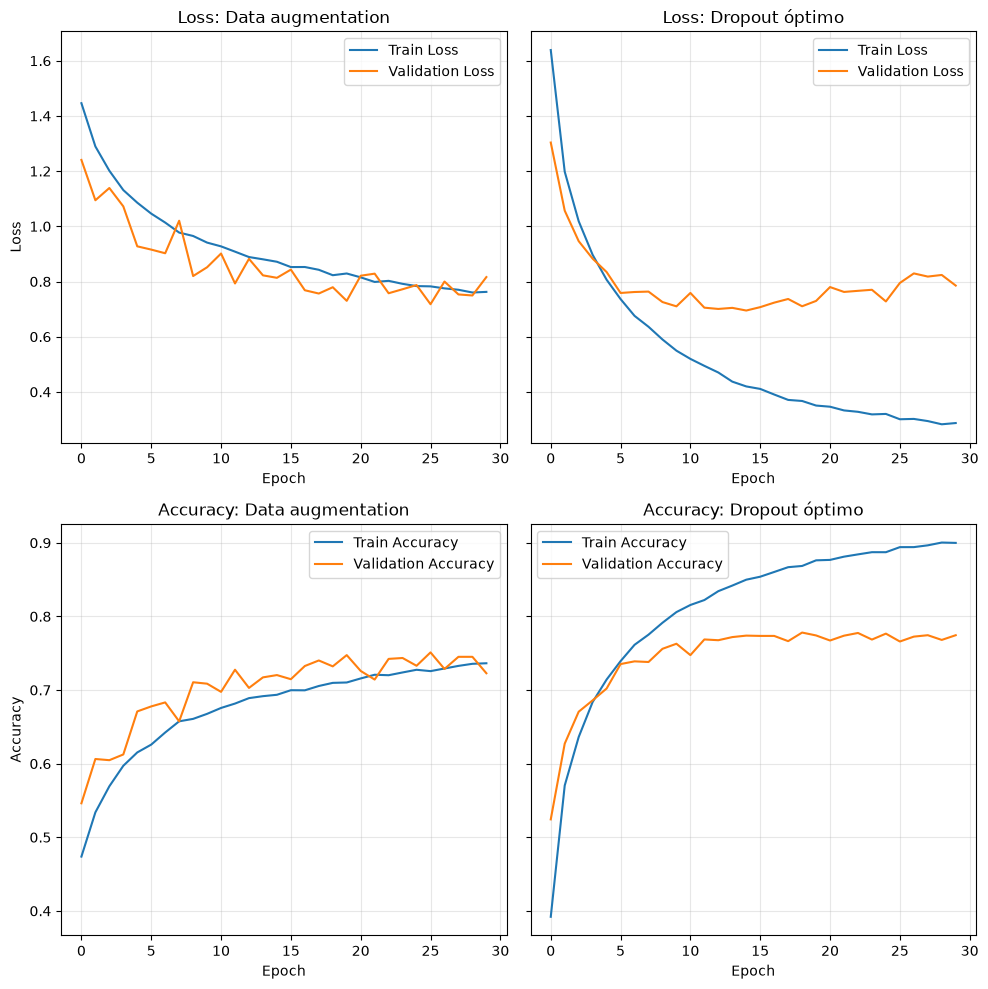

In [64]:
compare_metrics_side_by_side({'Data augmentation' : histDataAug, 'Dropout óptimo': history2})

In [65]:
show_test({'Data augmentation' : cnnDataAug, 'Dropout óptimo': cnnDropout2})

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7202 - loss: 0.8439

--- Resultados Finales en Test (Data augmentation) ---
Error (Loss) en Test): 0.8439
Precisión (Accuracy) en Test: 72.02%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7767 - loss: 0.7896

--- Resultados Finales en Test (Dropout óptimo) ---
Error (Loss) en Test): 0.7896
Precisión (Accuracy) en Test: 77.67%


## Conclusiones

Analizando ambos gráficos notamos algo claro: data augmentation minimiza el sobreajuste. Esto era esperado y la razón es clara, en cada época al hacerle una transformación aleatoria al dataset de entrenamiento, tenemos transformaciones de esos datos de entrenamiento (se pueden pensar directamente como datos distintos) lo cual sana el overfitting. Por otro lado, el modelo con el dropout óptimo vemos que a partir de la época 5 ya comienza a overfittear. Para la época 20, ya tenemos los siguientes valores:

| Modelo | Error train | Error val | Diferencia (Val − Train) |
|---|---|---|---|
| Dropout óptimo | 0.3505 | 0.7297 | +0.3792 |
| Data augmentation | 0.8291 | 0.7300 | −0.0991 |

Donde claramente el overfitting en el modelo de data augmentation es aproximadamente 0,099 lo cual es mucho menor al valor del modelo con dropout óptimo en esta época, el cual es de 0,3792.

Respecto a la mejora en el accuracy, a igualdad de épocas (30) no hay: el modelo aumentado alcanza 72.02% en test frente a 77.67% del dropout. Lo que creemos es que la red con data augmentation está sufriendo de subajuste, es decir, que necesita una mayor cantidad de épocas para converger a una buena accuracy. Esto también lo podemos ver ya que pareciera que la gráfica de loss de la izquierda decrece más lentamente que la de la derecha (tanto train como val error). 

Juntando esto, podemos ver que el data augmentation elimina casi completamente el sobreajuste. Sin embargo, probablemente le tome más épocas llegar a los mismos valores de accuracy que la red con el dropout óptimo. Pero también pensamos que con una cantidad suficiente de épocas, la red con data augmentation podría superar el accuracy de la red con dropout.

Dado más presupuesto de entrenamiento, el modelo con dropout no mejoraría (podemos ver que sobre el final de la época 30 ya empieza a sobreajustar), mientras que la red con data augmentation sí tiene recorrido. Por eso, cuando los datos son limitados, preferiríamos data augmentation ya que ofrece regularización "gratis" (sin parámetros extra) y sin un techo tan temprano.

## Ejercicio 4. Transfer Learning (Opcional, 2.5p)

Tome la red propuesta en un principio, quite todos los ejemplos de dos clases cualesquiera del CIFAR-10 para
quedar con 8 clases. Tomando este nuevo dataset entrene la red por completo como antes – recuerde que
ahora la capa densa final debe tener un tamaño de 8.

Tomando esta red entrenada para diferenciar entre 8 clases, queremos diferenciar ahora los ejemplos de las
dos clases restantes, y sólo éstas dos.
Primero intentaremos congelando todas las capas menos la última, de la siguiente forma:

``
model_cifar8.pop()
for layer in model_cifar8.layers:
layer.trainable = False
y reemplazaremos la capa densa final por una de 2 clases (lo siguiente vale sólo para modelos secuenciales
de Keras):
model_cifar2 = models.Sequential([
model_cifar8,
layers.Dense(2, activation='softmax')
])
``

Recuerde que siempre que modifica un modelo debe recompilarlo: model.compile(...).
Entrene por un número adecuado de épocas. Analice los resultados.


In [35]:
cantEpocas = 15

# Filtrar el dataset

# Clases a ELIMINAR (elegir 2 clases, entre 0 y 9)
clases_a_eliminar = random.sample(range(10), 2)
print("Clases a eliminar:", clases_a_eliminar)

# Crear mascaras para filtrar las clases que quedan, '~' es el operador que niega la mascara usada
mask_train = ~np.isin(y_train.flatten(), clases_a_eliminar)
mask_test = ~np.isin(y_test.flatten(), clases_a_eliminar)

# Aplicar mascaras
x_train_8 = x_train[mask_train]
y_train_8 = y_train[mask_train]
x_test_8 = x_test[mask_test]
y_test_8 = y_test[mask_test]

clases_a_eliminar = sorted(clases_a_eliminar)

# Crea un array de etiquetas nuevas (0, 1, 2, ..., 7)
# para usar sparse_categorical_crossentropy hace falta q las clases sean enteros consecutivos
y_train_8 = np.array([i - sum(1 for c in clases_a_eliminar if i > c) for i in y_train_8])
y_test_8 = np.array([i - sum(1 for c in clases_a_eliminar if i > c) for i in y_test_8])

# verificar nuevo dataset

print("Clases en y_train_8:", np.unique(y_train_8))
print("Número de ejemplos en train:", len(y_train_8))  # Debe ser 40000 (50000 - 10000 de las 2 clases)
print("Número de ejemplos en test:", len(y_test_8))    # Debe ser 8000 (10000 - 2000 de las 2 clases)


Clases a eliminar: [7, 8]
Clases en y_train_8: [0 1 2 3 4 5 6 7]
Número de ejemplos en train: 40000
Número de ejemplos en test: 8000


Ahora creamos nuestra CNN entrenada para predecir imagenes de CIFAR8.

In [25]:
# tomamos la red dada en un principio

model_cifar8 = create_cnn_model(num_classes=8)
model_cifar8.summary()

# Entrenar la red
optimizer = keras.optimizers.Adam(learning_rate=0.0001)

loss = keras.losses.SparseCategoricalCrossentropy()

metrics = [
    keras.metrics.SparseCategoricalAccuracy(name='accuracy')
]

# Compile the CNN model
model_cifar8.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

# Separamos en train y validación

# stratify se encarga que al hacer la division, en los subconjuntos resultantes se mantenga las proporciones
# de clases del conjunto original
x_train_processed, x_val_processed, y_train_processed, y_val_processed = \
    train_test_split(x_train_8, y_train_8, test_size=0.25, stratify=y_train_8)

print(len(x_train_processed), len(x_val_processed))

history = model_cifar8.fit(x_train_processed, y_train_processed, epochs=cantEpocas,
                  validation_data=(x_val_processed, y_val_processed), verbose=1)
print("Entrenamiento completado!!")

Model: "lccCIFAR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,248 (1.60 MB)

 Trainable params: 418,248 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

30000 10000
Epoch 1/15


I0000 00:00:1781564834.152404    2856 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_376731__.35


935/938 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2994 - loss: 1.7803

I0000 00:00:1781564839.396089    2855 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_376731__.35


938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3919 - loss: 1.5670 - val_accuracy: 0.4845 - val_loss: 1.3321
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5359 - loss: 1.2247 - val_accuracy: 0.5477 - val_loss: 1.1886
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5982 - loss: 1.0805 - val_accuracy: 0.6166 - val_loss: 1.0393
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6338 - loss: 0.9901 - val_accuracy: 0.6394 - val_loss: 0.9677
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6573 - loss: 0.9289 - val_accuracy: 0.6495 - val_loss: 0.9280
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6788 - loss: 0.8776 - val_accuracy: 0.6677 - val_loss: 0.9074
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6955 - loss: 0.8330 - val_accuracy: 0.6630 - val_loss: 0.9111
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7111 - loss: 0.7915 - val_accuracy: 0.6802 - val

In [18]:
lr_actual = 1e-3

Acá tenemos que guardar los pesos del modelo cifar8 de alguna manera, sino los entrenamientos consecutivos de redes con distinta cantidad de capas descongeladas se hacen sobre pesos actualizados, que no es lo que queremos.

In [34]:
# Guardamos los pesos del extractor (todas las capas menos la salida de 8)
pesos_extractor = [layer.get_weights() for layer in model_cifar8.layers[:-1]]


def make_transfer_model(n_descongelar, learning_rate=1e-5):

    base = create_cnn_model(num_classes=8)
    capas_base = base.layers[:-1]

    # Cargamos los pesos guardados, capa por capa (por posición, no por nombre)
    for layer, w in zip(capas_base, pesos_extractor):
        layer.set_weights(w)

    # Congelar todo, descongelar las últimas n
    for layer in capas_base:
        layer.trainable = False
    if n_descongelar > 0:
        # selecciona las ultimas n_descongelar capas del modelo base.
        for layer in capas_base[-n_descongelar:]:
            layer.trainable = True

    model = keras.Sequential(capas_base)
    model.add(layers.Dense(2, activation='softmax', name=f'salida_2clases_n{n_descongelar}'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_actual),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


Creamos el conjunto de train y validación para 2 clases

In [27]:
# 2 CLASES

# Filtrar solo las 2 clases eliminadas (0 y 1 en este ejemplo)
mask_train_2 = np.isin(y_train.flatten(), clases_a_eliminar)
mask_test_2 = np.isin(y_test.flatten(), clases_a_eliminar)

x_train_2 = x_train[mask_train_2]
y_train_2 = y_train[mask_train_2]
x_test_2 = x_test[mask_test_2]
y_test_2 = y_test[mask_test_2]

# Ajustar etiquetas a 0 y 1 (para 2 clases)
y_train_2 = (y_train_2 == clases_a_eliminar[1]).astype(int)  # 0 si es clase 0, 1 si es clase 1
y_test_2 = (y_test_2 == clases_a_eliminar[1]).astype(int)

x_train_processed_2, x_val_processed_2, y_train_processed_2, y_val_processed_2 = train_test_split(x_train_2, y_train_2, test_size=0.25, stratify=y_train_2)


Vemos que las 10 clases de cifar10 son: *avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco, camión*.

La idea del **transfer learning** es que si sacamos dos clases de esta lista y entrenamos una red que sepa reconocer las 8 restantes, y posteriormente deseamos añadir las clases quitadas, no haya que "hacer todo el trabajo" de nuevo, ya que hay ciertas clases que presentan similitudes, y podremos aprovechar que la red ya aprendió a reconocer estos rasgos en común. Por ejemplo, los camiones son "similares" a los autos, o los gatos son "similares" a los perros.

Inicialmente, vemos qué ocurriría si se intentara clasificar 2 nuevas clases nunca vistas por la red, sin que la red pueda aprender nada nuevo, sino que tiene el conocimiento aprendido en base a las 8 clases. Esto es, congelando todas las capas menos la última (la de output)

In [28]:
model_1 = make_transfer_model(1)


hist_1 = model_1.fit(
                  x_train_processed_2, y_train_processed_2,
                  epochs=cantEpocas,
                  validation_data=(x_val_processed_2, y_val_processed_2)
                  )
print("Entrenamiento completado!!")

# Ver capas entrenables, deberia mostrar que la ultima capa es la unica entrenable
model_1.summary(show_trainable=True)

Epoch 1/15


I0000 00:00:1781564980.186949    2857 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_454037__.35


229/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7517 - loss: 0.4989

I0000 00:00:1781564982.371332    2855 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_454037__.35


235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7528 - loss: 0.4976

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ salida_2clases_n1 (Dense)   │ (None, 2)             │        258 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 451,016 (1.72 MB)

 Trainable params: 16,770 (65.51 KB)

 Non-trainable params: 400,704 (1.53 MB)

 Optimizer params: 33,542 (131.03 KB)

In [29]:
def show_test_cifar2(testdict):

  for desc, mod in testdict.items():
    # Evaluamos el modelo con los datos de prueba, evaluate devuelve una lista donde el primer valor es el loss y el segundo la accuracy
      resultados_test = mod.evaluate(x_test_2, y_test_2, verbose=1)

      test_loss = resultados_test[0]
      test_accuracy = resultados_test[1]

      print(f"\n--- Resultados Finales en Test ({desc}) ---")
      print(f"Error (Loss) en Test): {test_loss:.4f}")
      print(f"Precisión (Accuracy) en Test: {test_accuracy * 100:.2f}%")

In [30]:
def show_test_cifar8(testdict):

  for desc, mod in testdict.items():
    # Evaluamos el modelo con los datos de prueba, evaluate devuelve una lista donde el primer valor es el loss y el segundo la accuracy
      resultados_test = mod.evaluate(x_test_8, y_test_8, verbose=1)

      test_loss = resultados_test[0]
      test_accuracy = resultados_test[1]

      print(f"\n--- Resultados Finales en Test ({desc}) ---")
      print(f"Error (Loss) en Test): {test_loss:.4f}")
      print(f"Precisión (Accuracy) en Test: {test_accuracy * 100:.2f}%")

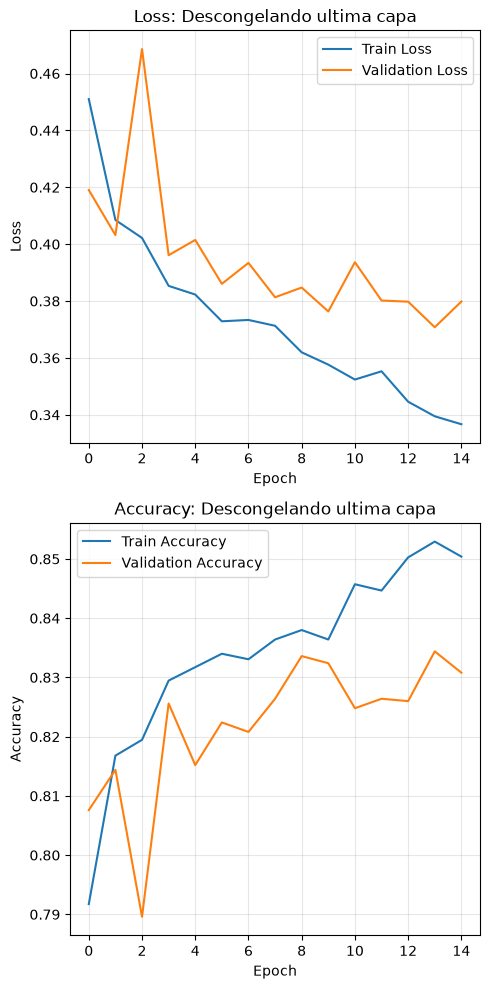

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8380 - loss: 0.3799

--- Resultados Finales en Test (Descongelando ultima capa) ---
Error (Loss) en Test): 0.3799
Precisión (Accuracy) en Test: 83.80%


In [31]:
# Mostramos los resultados para el análisis, congelando solo la ultima capa

compare_metrics_side_by_side({'Descongelando ultima capa' : hist_1})

show_test_cifar2({'Descongelando ultima capa' : model_1})



Observamos que la precisión de test es alta (más del $94\%$), esto se debe a que se trata de un problema de clasificación binaria, es decir que la red debe clasificar entre dos posibles clases, y al parecer la similitud entre alguna de las 8 clases presentes en el entrenamiento con las 2 clases quitadas, permite clasificar correctamente en la mayoría de los casos. Aún así, veremos si podemos mejorar aún más la precisión.

Luego repita lo anterior pero descongelando más capas hacia atrás.
Puede usar model.summary(show_trainable=True) para mostrar las capas entrenables.

¿Cuántas capas necesita descongelar para lograr resultados aceptables? ¿Es conveniente hacer ésto?
Analice los resultados

In [32]:
# Descongelamos 2 capas (la de output, y 1 mas)
model_2 = make_transfer_model(2)
hist_2 = model_2.fit(x_train_processed_2, y_train_processed_2, epochs=cantEpocas,
                     validation_data=(x_val_processed_2, y_val_processed_2))

# Descongelamos 4 capas
model_4 = make_transfer_model(4)
hist_4 = model_4.fit(x_train_processed_2, y_train_processed_2, epochs=cantEpocas,
                     validation_data=(x_val_processed_2, y_val_processed_2))

# Descongelamos 6 capas
model_6 = make_transfer_model(6)
hist_6 = model_6.fit(x_train_processed_2, y_train_processed_2, epochs=cantEpocas,
                     validation_data=(x_val_processed_2, y_val_processed_2))

# Descongelamos 8 capas
model_8 = make_transfer_model(8)
hist_8 = model_8.fit(x_train_processed_2, y_train_processed_2, epochs=cantEpocas,
                     validation_data=(x_val_processed_2, y_val_processed_2))

# Descongelamos 10 capas
model_10 = make_transfer_model(10)
hist_10 = model_10.fit(x_train_processed_2, y_train_processed_2, epochs=cantEpocas,
                     validation_data=(x_val_processed_2, y_val_processed_2))

Epoch 1/15


I0000 00:00:1781565004.572038    2857 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_475605__.35


225/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7701 - loss: 0.5053

I0000 00:00:1781565006.104299    2855 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_475605__.35


235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8041 - loss: 0.4392 - val_accuracy: 0.8036 - val_loss: 0.4187
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8259 - loss: 0.3894 - val_accuracy: 0.8192 - val_loss: 0.4031
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8320 - loss: 0.3803 - val_accuracy: 0.8196 - val_loss: 0.3998
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8419 - loss: 0.3644 - val_accuracy: 0.8188 - val_loss: 0.3987
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8372 - loss: 0.3645 - val_accuracy: 0.8300 - val_loss: 0.3815
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8464 - loss: 0.3501 - val_accuracy: 0.8324 - val_loss: 0.3767
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8516 - loss: 0.3419 - val_accuracy: 0.8160 - val_loss: 0.4068
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8515 - loss: 0.3384 - val_accuracy: 0.8200 - val

...

235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8279 - loss: 0.3960 - val_accuracy: 0.7836 - val_loss: 0.4524
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8687 - loss: 0.3199 - val_accuracy: 0.8680 - val_loss: 0.3215
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8963 - loss: 0.2618 - val_accuracy: 0.8544 - val_loss: 0.3285
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9059 - loss: 0.2284 - val_accuracy: 0.8796 - val_loss: 0.2890
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9253 - loss: 0.1901 - val_accuracy: 0.8768 - val_loss: 0.3588
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9361 - loss: 0.1637 - val_accuracy: 0.8872 - val_loss: 0.3318
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9488 - loss: 0.1284 - val_accuracy: 0.8848 - val_loss: 0.3329
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9551 - loss: 0.1190 - val_accuracy: 0.8712 - val

I0000 00:00:1781565077.516361    2856 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_563977__.35


224/235 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7281 - loss: 0.5617

I0000 00:00:1781565079.789166    2856 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_563977__.35


235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7891 - loss: 0.4501 - val_accuracy: 0.8460 - val_loss: 0.3522
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8541 - loss: 0.3374 - val_accuracy: 0.8488 - val_loss: 0.3479
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8829 - loss: 0.2891 - val_accuracy: 0.8820 - val_loss: 0.2880
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8971 - loss: 0.2554 - val_accuracy: 0.8716 - val_loss: 0.3139
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9083 - loss: 0.2261 - val_accuracy: 0.8784 - val_loss: 0.2968
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9240 - loss: 0.1910 - val_accuracy: 0.8884 - val_loss: 0.2697
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9312 - loss: 0.1704 - val_accuracy: 0.8880 - val_loss: 0.2935
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9469 - loss: 0.1408 - val_accuracy: 0.8880 - val

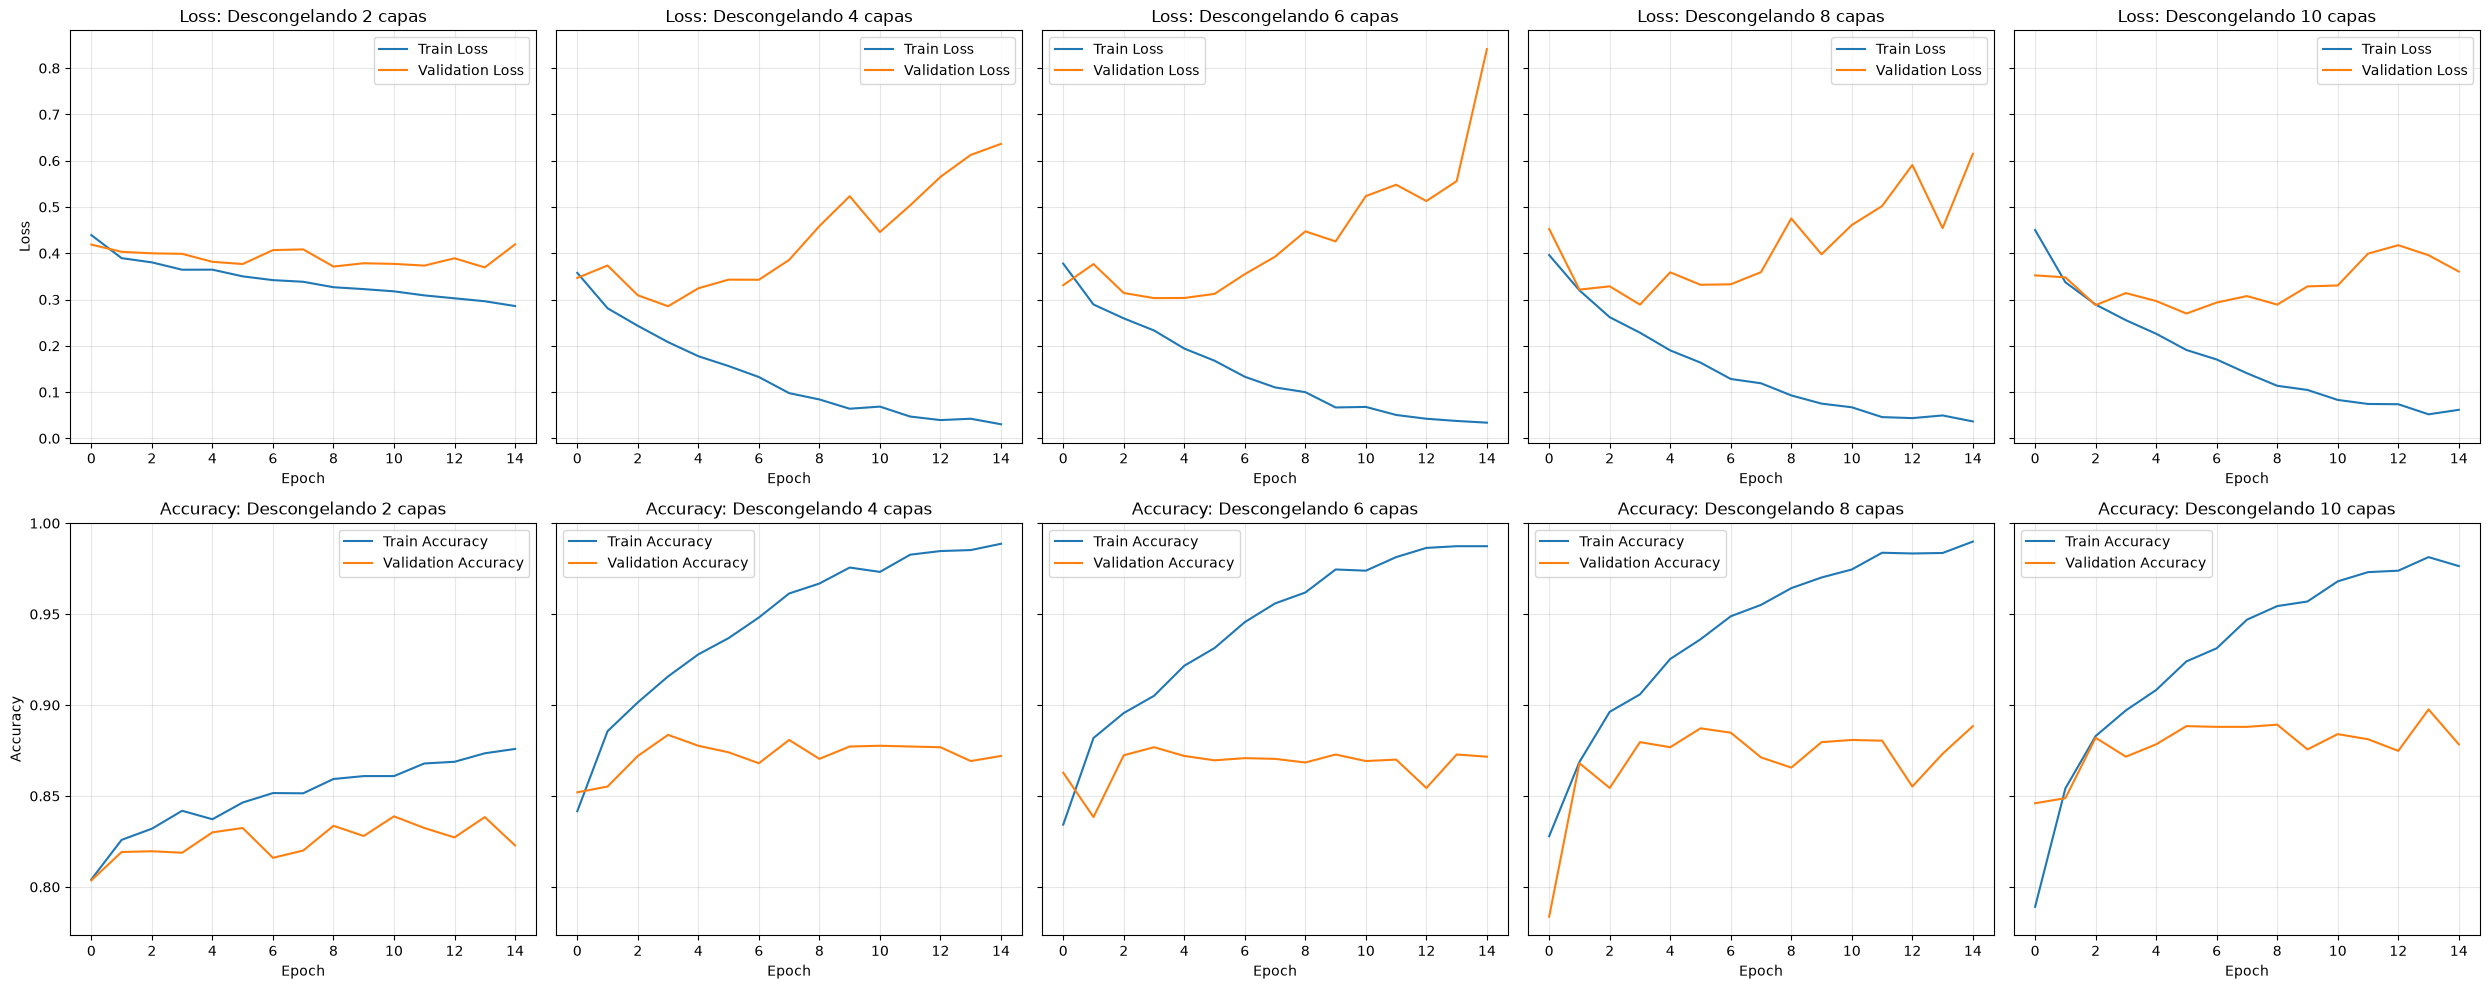

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8270 - loss: 0.4079

--- Resultados Finales en Test (Descongelando 2 capas) ---
Error (Loss) en Test): 0.4079
Precisión (Accuracy) en Test: 82.70%
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8880 - loss: 0.5876

--- Resultados Finales en Test (Descongelando 4 capas) ---
Error (Loss) en Test): 0.5876
Precisión (Accuracy) en Test: 88.80%
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8940 - loss: 0.6410

--- Resultados Finales en Test (Descongelando 6 capas) ---
Error (Loss) en Test): 0.6410
Precisión (Accuracy) en Test: 89.40%
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9045 - loss: 0.5580

--- Resultados Finales en Test (Descongelando 8 capas) ---
Error (Loss) en Test): 0.5580
Precisión (Accuracy) en Test: 90.45%
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8990 - loss: 0.3626

--- Resultados Finales en Test (Descongelando 10 capas) ---
Error (Loss) en Test): 0.3626
Precisión (Accuracy) en Test: 8

In [33]:
# Mostramos los resultados para el análisis
compare_metrics_side_by_side({'Descongelando 2 capas' : hist_2, 'Descongelando 4 capas' : hist_4,'Descongelando 6 capas' : hist_6, 'Descongelando 8 capas': hist_8 ,'Descongelando 10 capas': hist_10 })

show_test_cifar2({'Descongelando 2 capas' : model_2, 'Descongelando 4 capas' : model_4,'Descongelando 6 capas' : model_6, 'Descongelando 8 capas' : model_8, 'Descongelando 10 capas' : model_10})

## Conclusiones

Observamos que, en general, cuantas más capas descongelamos (permitiendo que la red reajuste los pesos de sus neuronas para adaptarse a las 2 nuevas clases), mayor es el accuracy y menor el loss en test. Esto se debe a que el modelo gana flexibilidad para aprender patrones específicos del nuevo problema.

Conceptualmente, las features genéricas (osea las de las primeras capas), son adaptables a predicciones de clases no vistas, ya que al ser genéricas se comparten entre muchos problemas distintos. En este caso particular, tener una red que tenga buena performance en la elección de $8$ clases necesita mayor capacidad de modelado que una que distinga entre $2$ clases, por lo tanto re-entrenar toda la red con menos clases normalmente lleva a que **sobreajuste** muy facilmente. En su lugar, el **fine-tuning** (descongelar solo algunas capas) permite adaptar el modelo de manera eficiente

Observemos que no tiene sentido congelar capas intermedias en nuestro caso: si una capa intermedia necesita ajustarse para representar mejor las nuevas clases, las capas posteriores también deben reentrenarse para interpretar correctamente esas nuevas representaciones.

Claramente en cuanto más capas descongelemos, más "trabajo adicional" deberá hacer la red, que es justamente el que **transfer learning** intenta minimizar. Entonces la idea es encontrar un buen valor $N$ de capas a descongelar tal que el **loss** de las muestras baje (y la precisión aumente), sin tener que aprender mucho más de lo que ya teníamos de antemano. Un buen valor podría ser $N=4$, donde se tiene más de $88\%$ de accuracy y aproximadamente $0.59$ de loss, teniendo que descongelar menos de la mitad de las capas de la red.

## Otro experimento que surge

En lugar de elegir las 2 clases a separar al azar, repetimos el experimento de transfer learning con dos pares de clases de dificultad opuesta, para estudiar cómo influye la similitud entre las clases en la efectividad del transfer learning. Para esto, elegimos estos dos casos de prueba:

- Clases parecidas: gato y perro.
- Clases distintas: avión y gato.

En ambos casos entrenamos primero la red base sobre las 8 clases restantes y luego hacemos fine-tuning sobre las 2 clases quitadas, descongelando progresivamente 1, 2, 4, 6, 8 y 10 capas.

Además, se nos ocurrió hacer un mini experimento para testear una hipótesis que tuvimos: a medida que descongelamos más capas, mientras incrementa el accuracy sobre CIFAR2, debería disminuir sobre CIFAR8.

Desde el punto de vista conceptual es obvio: originalmente teníamos una red entrenada para clasificar CIFAR8. Descongelando capas, fuimos modificando esos pesos de las últimas capas para que clasifique correctamente CIFAR2, desviando la clasificación de CIFAR8 a una más incorrecta.

Respecto al código, investigamos y encontramos una técnica que se llama "linear probe". Nos quedamos con la red fine-tuneada (todas las capas menos la softmax de 2 clases), congelamos TODAS SUS CAPAS, y entrenamos sobre él un nuevo clasificador lineal (una única capa softmax de 8 clases) usando los datos de CIFAR-8. De esta forma, medimos cuánta información sobre las 8 clases originales sobrevive en la red tras el fine-tuning. Al restringir el clasificador a ser lineal, medimos qué tan separables linealmente siguen siendo esas clases.

In [ ]:
# Experimento: transfer learning con clases parecidas (gato/perro) vs distintas (avión/gato)
# Reutiliza create_cnn_model, x_train, y_train, x_test, y_test definidos antes.

EP = 15
FREEZE = [1, 2, 4, 6, 8, 10]

def run_experiment(clases_a_eliminar):
    clases = sorted(clases_a_eliminar)

    # --- CIFAR-8 (las otras 8 clases) ---
    mtr = ~np.isin(y_train, clases); mte = ~np.isin(y_test, clases)
    x8tr_full, y8tr_full = x_train[mtr], y_train[mtr]
    x8te, y8te = x_test[mte], y_test[mte]
    remap = lambda i: i - sum(1 for c in clases if i > c)
    y8tr_full = np.array([remap(i) for i in y8tr_full]); y8te = np.array([remap(i) for i in y8te])

    xtr, xval, ytr, yval = train_test_split(x8tr_full, y8tr_full, test_size=0.25, stratify=y8tr_full)
    base = create_cnn_model(num_classes=8)
    base.compile(optimizer=keras.optimizers.Adam(1e-4),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    base.fit(xtr, ytr, epochs=EP, validation_data=(xval, yval), verbose=0)
    _, acc8_base = base.evaluate(x8te, y8te, verbose=0)
    pesos = [l.get_weights() for l in base.layers[:-1]]

    # --- CIFAR-2 (las 2 clases quitadas) ---
    mtr2 = np.isin(y_train, clases); mte2 = np.isin(y_test, clases)
    x2tr_full, y2tr_full = x_train[mtr2], y_train[mtr2]
    x2te, y2te = x_test[mte2], (y_test[mte2] == clases[1]).astype(int)
    y2tr_full = (y2tr_full == clases[1]).astype(int)
    x2tr, x2val, y2tr, y2val = train_test_split(x2tr_full, y2tr_full, test_size=0.25, stratify=y2tr_full)
    x8ptr, x8pval, y8ptr, y8pval = train_test_split(x8tr_full, y8tr_full, test_size=0.25, stratify=y8tr_full)

    def make_transfer(n):
        b = create_cnn_model(num_classes=8); cb = b.layers[:-1]
        for l, w in zip(cb, pesos): l.set_weights(w)
        for l in cb: l.trainable = False
        if n > 0:
            for l in cb[-n:]: l.trainable = True
        m = keras.Sequential(cb)
        m.add(layers.Dense(2, activation='softmax', name=f'salida_n{n}'))
        m.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return m

    def linear_probe(ft):  # mide retención de CIFAR-8 congelando el extractor fine-tuneado
        ext = ft.layers[:-1]
        for l in ext: l.trainable = False
        p = keras.Sequential(ext); p.add(layers.Dense(8, activation='softmax', name='probe8'))
        p.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        p.fit(x8ptr, y8ptr, epochs=EP, validation_data=(x8pval, y8pval), verbose=0)
        return p

    res = {}
    for n in FREEZE:
        m = make_transfer(n)
        h = m.fit(x2tr, y2tr, epochs=EP, validation_data=(x2val, y2val), verbose=0)
        _, a2 = m.evaluate(x2te, y2te, verbose=0)
        _, a8 = linear_probe(m).evaluate(x8te, y8te, verbose=0)
        res[n] = (h, a2, a8)
    return acc8_base, res

acc8_par, res_par = run_experiment([3, 5])    # gato, perro (parecidas)
acc8_dist, res_dist = run_experiment([0, 3])  # avión, gato (distintas)

### Resultados

**Clases parecidas (gato/perro)**

| Capas descong. | CIFAR-2 acc | CIFAR-2 loss | CIFAR-8 con linear probe |
|---|---|---|---|
| 1 | 67.50% | 0.6036 | 76.23% |
| 2 | 67.55% | 0.6150 | 74.16% |
| 4 | 73.90% | 1.0285 | 41.48% |
| 6 | 72.80% | 1.1356 | 32.46% |
| 8 | 75.25% | 1.0773 | 30.70% |
| 10 | 77.95% | 1.0749 | 25.28% |

**Clases distintas (avión/gato)**

| Capas descong. | CIFAR-2 acc | CIFAR-2 loss | CIFAR-8 con linear probe |
|---|---|---|---|
| 1 | 91.30% | 0.2070 | 74.77% |
| 2 | 91.30% | 0.2248 | 73.12% |
| 4 | 93.10% | 0.2635 | 45.34% |
| 6 | 95.05% | 0.2898 | 35.60% |
| 8 | 93.30% | 0.3161 | 38.54% |
| 10 | 93.25% | 0.3372 | 36.29% |

### Gráficos

Comparación CIFAR-2 y linear probe en CIFAR8, según capas descongeladas:

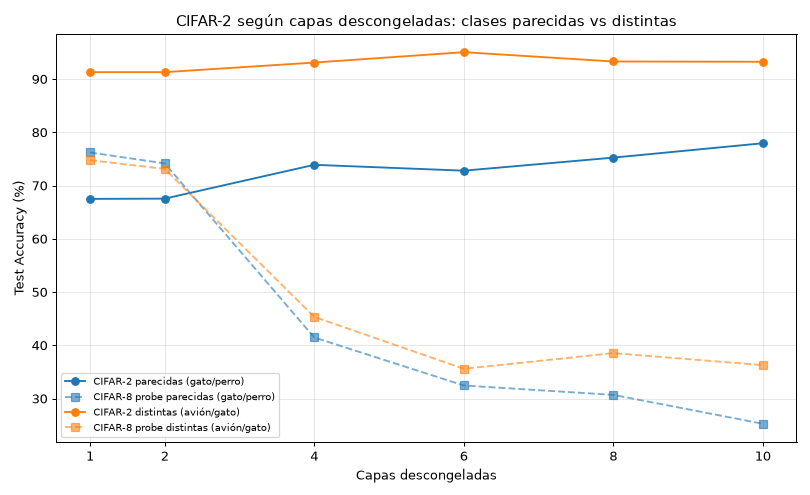

Curvas de entrenamiento de los 6 modelos con clases parecidas (gato/perro):

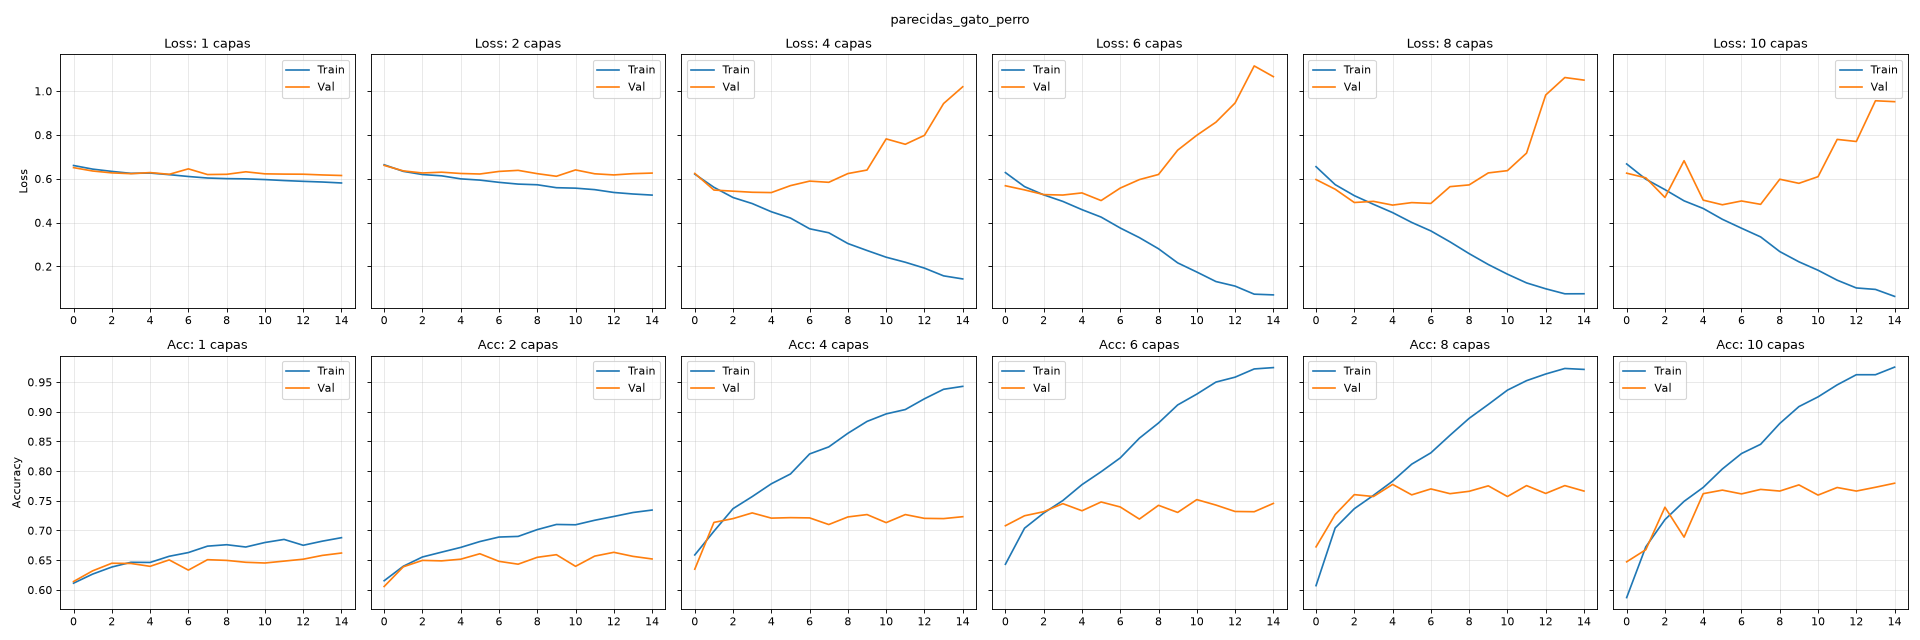

Curvas de entrenamiento de los 6 modelos con clases distintas (avión/gato):

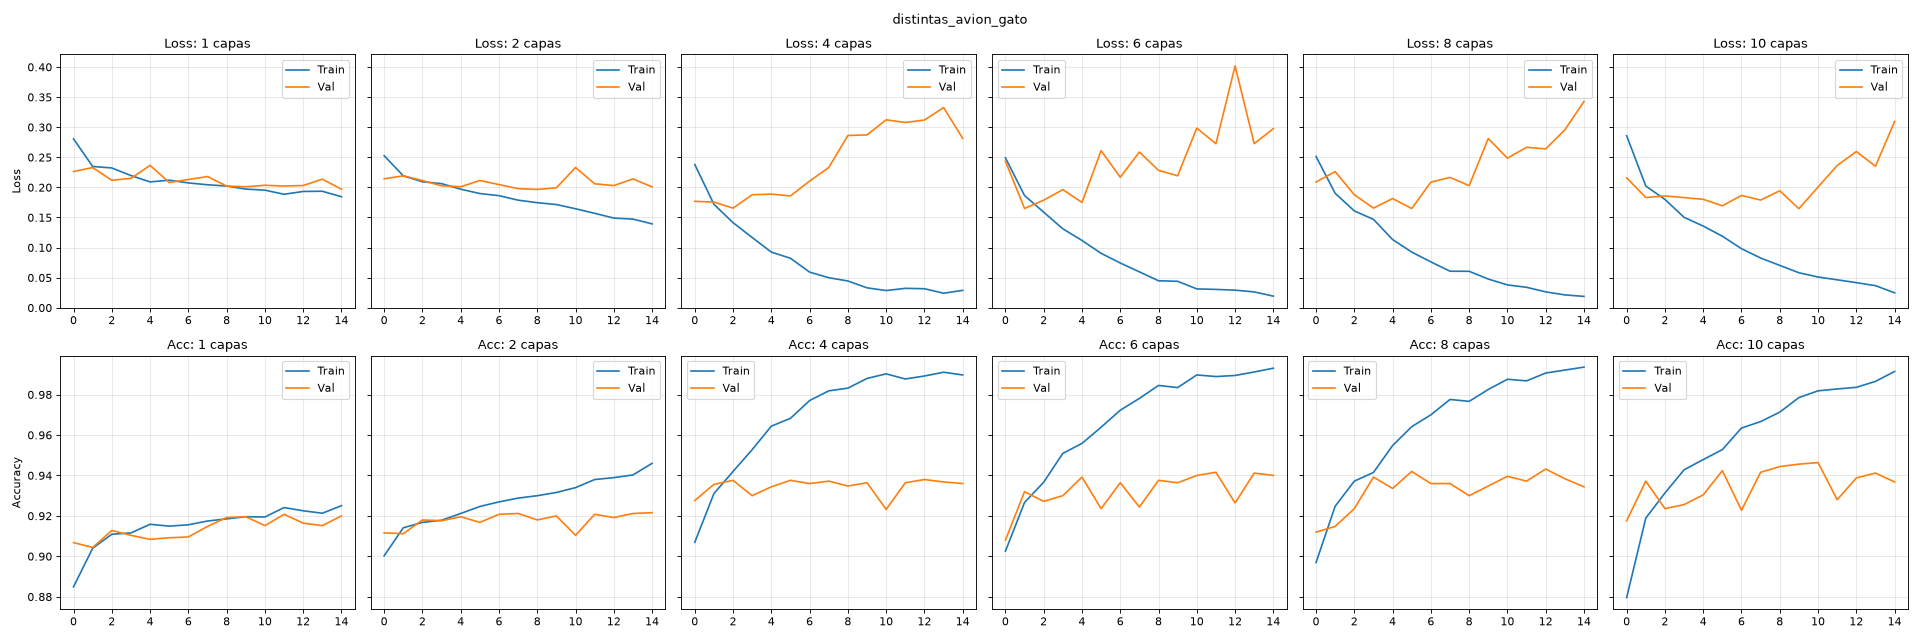

## Conclusión

**Clases distintas**: el transfer learning funciona casi perfecto desde el primer nivel. Con solo la última capa descongelada (n=1) ya se alcanza 92%, y descongelar más capas apenas mejora. Esto indica que las características aprendidas sobre las otras 8 clases ya separan bien un vehículo de un animal. El conocimiento previo es directamente reutilizable.

**Clases parecidas**: el transfer learning cuesta muchísimo más. Con n=1 se obtiene apenas 67%, y el accuracy crece con cada capa descongelada, necesitando descongelar las 10 capas para llegar a 77%. La razón detrás de esto es que las características que aprendió de los otros animales en CIFAR-8 (pájaro, ciervo, rana, caballo) capturan rasgos genéricos de "animal" pero no los detalles que distinguen un gato de un perro. Esa distinción debe re-aprenderse en las capas más profundas, lo que solo es posible descongelándolas.

**Conclusión general**: la efectividad del transfer learning depende de qué tan separables son las clases nuevas con las features ya aprendidas, no solo de la similitud visual. Para un problema de clasificación muy distinto (animal vs vehículo) basta con re-entrenar la capa de salida, lo cual es barato y efectivo. Para un problema más detallado (dos animales parecidos) hay que descongelar casi toda la red, perdiendo gran parte de la ventaja del transfer learning.

Como supusimos, la red a medida que más capas descongela para re-entrenar un nuevo problema de clasificación, pierde accuracy clasificando las 8 clases originales (lo medimos con el linear probe). Cabe aclarar que la proporción no es lineal: ganar unos pocos puntos de accuracy en CIFAR-2 puede costar muchos puntos de accuracy en CIFAR-8. Por ejemplo, al pasar de 2 a 4 capas descongeladas, en clases distintas (avión/gato) se gana apenas 1.8% en CIFAR-2 pero se pierde 27.8% en CIFAR-8. En clases parecidas (gato/perro), 6.4% en CIFAR-2 a costa de 32.7% en CIFAR-8.

Se ve un patrón claro: con n=1-2 (solo capas densas cercanas a la salida) la retención se mantiene casi intacta (~75%), pero a partir de n=4 (capas más profundas) se desploma. El contraste: en clases distintas hay un punto óptimo (n=1-2 da máximo CIFAR-2 con CIFAR-8 preservado), mientras que en parecidas no lo hay.

Cabe aclarar que el linear probe mide la información linealmente separable en las features, por lo que los valores de accuracy sobre CIFAR-8 son una cota inferior de la información que permanece.

Además, re-entrenar más capas es más costoso computacionalmente. Esto sumado a la gran pérdida de retención (en el sentido de retención de los conocimientos anteriores sobre CIFAR-8) frente a la poca ganancia en CIFAR-2, descongelar profundo no vale la pena salvo que el problema nuevo lo exija (como en las clases parecidas).